## Análisis de datos - Clase 4

---
### Introducción a Machine Learning parte II
---
#### Split de un dataset


In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [131]:
# Cargamos el dataset de Titanic de Seaborn
titanic = sns.load_dataset("titanic")

In [132]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
#### Split con $\texttt{sklearn}$
---

#### Ejemplo: problema de clasificación
* Target: $\texttt{survived}$ (0=No, 1=Sí). 
* Features: $\texttt{pclass, sex, age, fare,}$ etc.

In [133]:
# Seleccionamos algunos features para el ejemplo
features = ['pclass', 'age', 'fare', 'sibsp', 'parch']
target   = 'survived'

df = titanic[features + [target]].dropna()

X = df[features]
y = df[target]

print(f"Dimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")

Dimensión de X: (714, 5)
Dimensión de y: (714,)


In [134]:
X.head()

,pclass,age,fare,sibsp,parch
0,3,22.0,7.2500,1,0
1,1,38.0,71.2833,1,0
2,3,26.0,7.9250,0,0
3,1,35.0,53.1000,1,0
4,3,35.0,8.0500,0,0


In [135]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20, # 80% entrenamiento, 20% para test (también se suele usar 70/30 o 75/25)
    random_state=42, # semilla para reproducibilidad (para que el split se haga siempre igual)
    shuffle = True, # mezclar antes de hacer el split (por defecto es True)
    stratify = None # ya veremos qué hace!
)

print("Verificamos el split 80-20")
print(f"Dataset completo : {len(X)} filas")
print(f"X_train            : {X_train.shape[0]} filas, {X_train.shape[1]} columnas  ({X_train.shape[0]/len(X):.0%})")
print(f"X_test             : {X_test.shape[0]} filas, {X_test.shape[1]} columnas   ({X_test.shape[0]/len(X):.0%})")
print(f"y_train            : {(pd.DataFrame(y_train).shape[0])} filas, {pd.DataFrame(y_train).shape[1]} columna(s)  ({pd.DataFrame(y_train).shape[0]/len(y):.0%})")
print(f"y_test             : {pd.DataFrame(y_test).shape[0]} filas, {pd.DataFrame(y_test).shape[1]} columna(s)   ({pd.DataFrame(y_test).shape[0]/len(y):.0%})")


Verificamos el split 80-20
Dataset completo : 714 filas
X_train            : 571 filas, 5 columnas  (80%)
X_test             : 143 filas, 5 columnas   (20%)
y_train            : 571 filas, 1 columna(s)  (80%)
y_test             : 143 filas, 1 columna(s)   (20%)


In [137]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y,
    test_size=0.20, # 80% entrenamiento, 20% para test (también se suele usar 70/30 o 75/25)
    random_state=42, # semilla para reproducibilidad (para que el split se haga siempre igual)
    shuffle = True, # mezclar antes de hacer el split (por defecto es True)
    stratify = y # ya veremos qué hace!
)

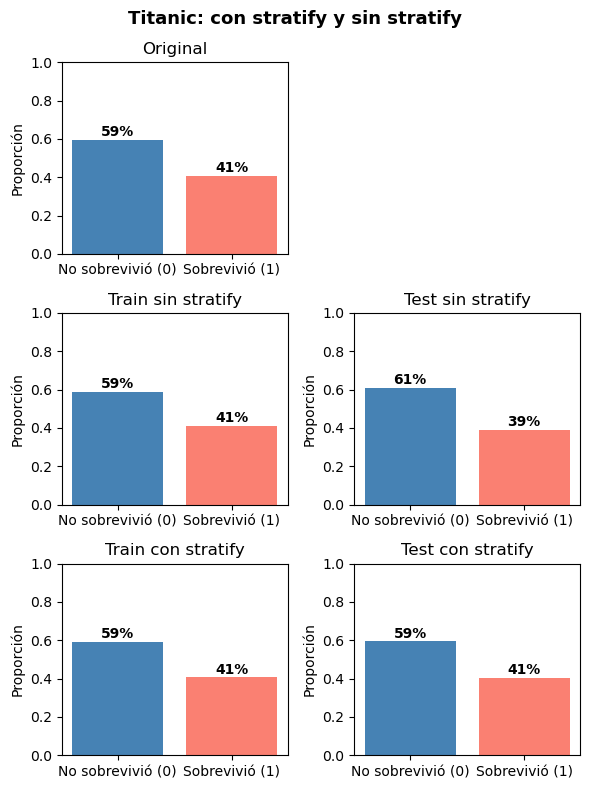

In [138]:

fig, axes = plt.subplots(3, 2, figsize=(6, 8))

# Fila 0: Original centrado, ocultamos el eje derecho
axes[0, 1].set_visible(False)
ax_orig = axes[0, 0]
proporciones = y.value_counts(normalize=True).sort_index()
ax_orig.bar(
    ['No sobrevivió (0)', 'Sobrevivió (1)'],
    proporciones.values,
    color=['steelblue', 'salmon']
)
ax_orig.set_title('Original')
ax_orig.set_ylim(0, 1)
ax_orig.set_ylabel('Proporción')
for i, v in enumerate(proporciones.values):
    ax_orig.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Fila 1: sin stratify
datasets_sin = {
    'Train sin stratify': y_train,
    'Test sin stratify':  y_test,
}
for ax, (titulo, serie) in zip(axes[1], datasets_sin.items()):
    proporciones = serie.value_counts(normalize=True).sort_index()
    ax.bar(
        ['No sobrevivió (0)', 'Sobrevivió (1)'],
        proporciones.values,
        color=['steelblue', 'salmon']
    )
    ax.set_title(titulo)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proporción')
    for i, v in enumerate(proporciones.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Fila 2: con stratify
datasets_con = {
    'Train con stratify': y_train_s,
    'Test con stratify':  y_test_s,
}
for ax, (titulo, serie) in zip(axes[2], datasets_con.items()):
    proporciones = serie.value_counts(normalize=True).sort_index()
    ax.bar(
        ['No sobrevivió (0)', 'Sobrevivió (1)'],
        proporciones.values,
        color=['steelblue', 'salmon']
    )
    ax.set_title(titulo)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proporción')
    for i, v in enumerate(proporciones.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

plt.suptitle('Titanic: con stratify y sin stratify', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Veamos otro caso (dataset desbalanceado y pequeñ0)

In [139]:
df_desbal = pd.concat([
    df[df['survived'] == 0].sample(20, random_state=10),
    df[df['survived'] == 1].sample(6, random_state=10)
])
X_desbal = df_desbal[features]
y_desbal = df_desbal[target]

X_train_sin, X_test_sin, y_train_sin, y_test_sin = train_test_split(X_desbal, y_desbal, test_size=0.30, random_state=42, stratify=None)
X_train_con, X_test_con, y_train_con, y_test_con = train_test_split(X_desbal, y_desbal, test_size=0.30, random_state=42, stratify=y_desbal)

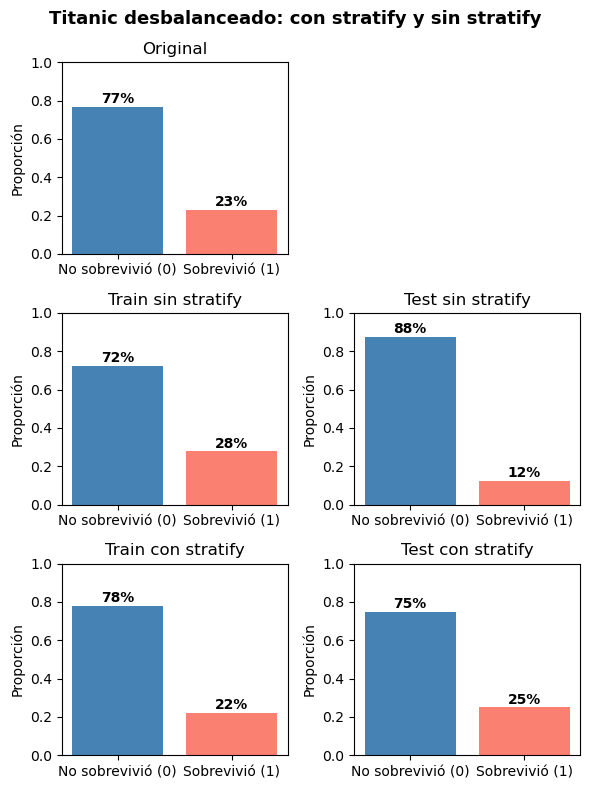

In [140]:
fig, axes = plt.subplots(3, 2, figsize=(6, 8))

axes[0, 1].set_visible(False)
ax_orig = axes[0, 0]
proporciones = y_desbal.value_counts(normalize=True).sort_index()
ax_orig.bar(
    ['No sobrevivió (0)', 'Sobrevivió (1)'],
    proporciones.values,
    color=['steelblue', 'salmon']
)
ax_orig.set_title('Original')
ax_orig.set_ylim(0, 1)
ax_orig.set_ylabel('Proporción')
for i, v in enumerate(proporciones.values):
    ax_orig.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Fila 1: sin stratify
datasets_sin = {
    'Train sin stratify': y_train_sin,
    'Test sin stratify':  y_test_sin,
}
for ax, (titulo, serie) in zip(axes[1], datasets_sin.items()):
    proporciones = serie.value_counts(normalize=True).sort_index()
    ax.bar(
        ['No sobrevivió (0)', 'Sobrevivió (1)'],
        proporciones.values,
        color=['steelblue', 'salmon']
    )
    ax.set_title(titulo)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proporción')
    for i, v in enumerate(proporciones.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Fila 2: con stratify
datasets_con = {
    'Train con stratify': y_train_con,
    'Test con stratify':  y_test_con,
}
for ax, (titulo, serie) in zip(axes[2], datasets_con.items()):
    proporciones = serie.value_counts(normalize=True).sort_index()
    ax.bar(
        ['No sobrevivió (0)', 'Sobrevivió (1)'],
        proporciones.values,
        color=['steelblue', 'salmon']
    )
    ax.set_title(titulo)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Proporción')
    for i, v in enumerate(proporciones.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

plt.suptitle('Titanic desbalanceado: con stratify y sin stratify', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()